## Imports

In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import matplotlib.mlab   as mlab

from xkte_nonadaptive import kernel_dr_two_sample_test_agnostic
from dr_kte_adaptive import xMMD2_vsdr_fold_generic
from baselines import cadr_test, hadad_test, fit_krr_predict
from sklearn.metrics import pairwise_distances

from scipy.spatial.distance import cdist
from scipy.special import expit
from scipy.stats import bernoulli
from numpy.polynomial.polynomial import polyval
from sklearn.linear_model import LogisticRegression

from scipy.stats import norm
import scipy.stats as stats
import statistics

from tqdm import tqdm

import seaborn as sns
import pandas as pd
import time
import os

In [2]:
import numpy as np

def treatment_effect_vector(ns, scenario, rng, beta_mix=1.0, beta_uniform=2.0):
    """
    Per-time treatment effect δ[t]; Y1 = base + δ, Y0 = base.
    scenario ∈ {'I','II','III','IV'}.
    """
    if scenario == 'I':
        return np.zeros(ns)
    if scenario == 'II':
        return np.full(ns, 1)
    if scenario == 'III':
        signs = rng.binomial(1, 0.5, size=ns) * 2 - 1
        return signs.astype(float) * beta_mix
    if scenario == 'IV':
        return rng.uniform(-beta_uniform, beta_uniform, size=ns)
    return np.zeros(ns)


def collect_epsilon_greedy(
    ns, d, beta_vec, noise_var, scenario,
    eps0=0.2, eps_min=0.05, power=0.99, lam=1e-2, rng=None,
    split="alternating", one_indexed=True
):
    """
    ε-greedy (2 arms) with per-arm online ridge (no clipping).
    """
    rng = rng or np.random.RandomState(0)

    # contexts and potential outcomes (linear base)
    X = rng.randn(ns, d)
    base = np.cos(X @ beta_vec)
    delta = treatment_effect_vector(ns, scenario, rng)
    Y0 = base + noise_var * rng.randn(ns)
    Y1 = base + noise_var * rng.randn(ns) + delta

    # ---- add bias feature and keep it unpenalized ----
    X_aug = np.hstack([np.ones((ns, 1)), X])  # [1, x]

    # online ridge state per arm (0 penalty on bias coord)
    S0 = np.diag([0.0] + [lam]*d); S1 = np.diag([0.0] + [lam]*d)
    b0 = np.zeros(d+1);            b1 = np.zeros(d+1)

    def solve_theta(S, b):
        try:
            return np.linalg.solve(S, b)
        except np.linalg.LinAlgError:
            return np.linalg.lstsq(S, b, rcond=None)[0]

    def eps_at(t):
        return max(eps_min, eps0 / ((t + 1) ** power))

    # logs + parameter snapshots
    T = np.zeros(ns, dtype=int)       # action (0/1)
    w = np.zeros(ns, dtype=float)     # π_t(1|X_t) at decision time t
    Y = np.zeros(ns, dtype=float)
    theta0_snap = np.zeros((ns, d+1))
    theta1_snap = np.zeros((ns, d+1))

    for t in range(ns):
        th0 = solve_theta(S0, b0)
        th1 = solve_theta(S1, b1)
        theta0_snap[t] = th0
        theta1_snap[t] = th1

        eps_t = eps_at(t)
        z_t = X_aug[t]
        q0 = z_t @ th0
        q1 = z_t @ th1
        if q1 > q0:
            pi1 = 1.0 - 0.5 * eps_t
        elif q1 < q0:
            pi1 = 0.5 * eps_t
        else:
            pi1 = 0.5

        a = 1 if rng.rand() < pi1 else 0
        T[t] = a
        w[t] = pi1                        # propensity for action=1 (used with s_obs branching)

        y_t = Y1[t] if a == 1 else Y0[t]
        Y[t] = y_t

        if a == 0:
            S0 += np.outer(z_t, z_t); b0 += z_t * y_t
        else:
            S1 += np.outer(z_t, z_t); b1 += z_t * y_t

    # --- choose folds
    if split == "alternating":
        idx0 = np.arange(0, ns, 2)                 # odd times in 1-based → 0,2,4,...
        idx1 = np.arange(1, ns, 2)                 # even times → 1,3,5,...
    elif split == "chronological":
        cut = ns // 2
        idx0 = np.arange(0, cut)
        idx1 = np.arange(cut, ns)
    else:
        raise ValueError("split must be 'alternating' or 'chronological'.")

    # fold views (chronological inside each fold) — use augmented X for propensities
    Z0, Z1 = X_aug[idx0], X_aug[idx1]

    # build Π_{fold←fold}: rows = evaluation times t in that fold (chrono),
    # columns = contexts from the same fold (chrono)
    N0, N1 = idx0.size, idx1.size
    Pi_fold0_on_0 = np.empty((N0, N0))
    for r, t in enumerate(idx0):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0 = Z0 @ th0; q1 = Z0 @ th1
        Pi_fold0_on_0[r] = np.where(q1 > q0, 1.0 - 0.5 * eps_t,
                                    np.where(q1 < q0, 0.5 * eps_t, 0.5))

    Pi_fold1_on_1 = np.empty((N1, N1))
    for r, t in enumerate(idx1):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0 = Z1 @ th0; q1 = Z1 @ th1
        Pi_fold1_on_1[r] = np.where(q1 > q0, 1.0 - 0.5 * eps_t,
                                    np.where(q1 < q0, 0.5 * eps_t, 0.5))

    P_all = np.empty((ns, ns), dtype=np.float32)

    for t in range(ns):
        th0 = theta0_snap[t]; th1 = theta1_snap[t]; eps_t = eps_at(t)
        q0_all = X_aug @ th0
        q1_all = X_aug @ th1
        P_all[t] = np.where(q1_all > q0_all, 1.0 - 0.5 * eps_t,
                     np.where(q1_all < q0_all, 0.5 * eps_t, 0.5))
    return X, T, Y[:, None], w, Pi_fold0_on_0, Pi_fold1_on_1, idx0, idx1, P_all

## Main function, which runs a list of tests based on its arguments

In [12]:
import os, time
import numpy as np
import pandas as pd
from sklearn.metrics import pairwise_distances

def run_tests_adaptive(
    b_list, method_list, ns_list,
    name_folder, num_experiments, iterations,
    seed: int = 0,
    split: str = "alternating",          # 'alternating' or 'chronological'
    one_indexed: bool = True
):
    if split not in ("alternating", "chronological"):
        raise ValueError("split must be 'alternating' or 'chronological'.")

    noise_var = 0.5
    d = 5
    beta_vec = np.array([0.1, 0.2, 0.3, 0.4, 0.5])
    os.makedirs(name_folder, exist_ok=True)

    rng = np.random.RandomState(seed)

    for b in b_list:
        print('b = ', b)
        for method in method_list:
            for ns in ns_list:
                p_values = np.zeros(num_experiments)
                values   = np.zeros(num_experiments)
                times    = np.zeros(num_experiments)

                for n in range(num_experiments):

                    # ----- data + fold-aligned policy matrices for the requested split
                    X, T, Y, w, Pi_0_on_0, Pi_1_on_1, idx0, idx1, P_all = collect_epsilon_greedy(
                        ns=ns, d=d, beta_vec=beta_vec, noise_var=noise_var, scenario=b,
                        eps0=0.5, eps_min=0.2, power=0.5, lam=1e-1, rng=rng,
                        split=split, one_indexed=one_indexed
                    )

                    # Ensure shapes (N,1)
                    if Y.ndim == 1:
                        Y = Y[:, None]

                    # Gaussian RBF kernel bandwidth on Y blocks
                    YY0 = Y[T == 0]
                    YY1 = Y[T == 1]
                    sigma2 = np.median(pairwise_distances(YY0, YY1, metric='euclidean'))**2
                    if not np.isfinite(sigma2) or sigma2 <= 0:
                        sigma2 = float(np.var(Y)) + 1e-6


                    y = Y.reshape(-1)
                    # ============ METHODS ============ #
                    t0 = time.time()
                    if method == 'VS-DR-KTE':
                        # Always-stabilized, adaptive-aware, with chosen split
                        value = xMMD2_vsdr_fold_generic(
                            Y=Y, w=w, X=X, A=T,
                            kernel_function='rbf',
                            # fold-wise evaluation policies (chrono×chrono) for the two folds
                            Pi_0_on_0=Pi_0_on_0,
                            Pi_1_on_1=Pi_1_on_1,
                            # fold indices (0-based, chronological within each)
                            idx0=idx0,
                            idx1=idx1,
                            # outcome-kernel parameter (same as before)
                            gamma=1.0/sigma2,
                        )
                        from math import erf, sqrt
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == 'DR-xKTE':
                        value, p_value = kernel_dr_two_sample_test_agnostic(
                            Y, X, T, kernel_function='rbf', gamma=1.0/sigma2, verbose=False
                        )
                        from math import erf, sqrt
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == 'CADR':
                        # before fitting m0_hat, m1_hat
                        Dx = pairwise_distances(X, X, metric='euclidean')**2
                        med2_x = np.median(Dx[np.triu_indices_from(Dx, k=1)])
                        gamma_x = 1.0 / max(med2_x, 1e-6)

                        # KRR nuisances
                        m0_hat = fit_krr_predict(X[T==0], y[T==0], X, kernel_function='rbf', gamma=gamma_x, lam=1e-4) \
                                if np.any(T==0) else np.full(X.shape[0], y.mean())
                        m1_hat = fit_krr_predict(X[T==1], y[T==1], X, kernel_function='rbf', gamma=gamma_x, lam=1e-4) \
                                if np.any(T==1) else np.full(X.shape[0], y.mean())
                        out = cadr_test(
                            X=X, A=T, Y=y,
                            p_realized=w.reshape(-1),
                            m0=m0_hat, m1=m1_hat,
                            P_all=P_all
                        )
                        value  = out['stat']     # z-like
                        from math import erf, sqrt
                        # Phi = lambda z: 0.5*(1.0 + erf(z/np.sqrt(2.0)))
                        # p_two_sided = 2.0*(1.0 - Phi(abs(value)))
                        # p_value=p_two_sided
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))

                    elif method == 'Hadad':
                        # before fitting m0_hat, m1_hat
                        Dx = pairwise_distances(X, X, metric='euclidean')**2
                        med2_x = np.median(Dx[np.triu_indices_from(Dx, k=1)])
                        gamma_x = 1.0 / max(med2_x, 1e-6)

                        # KRR nuisances
                        m0_hat = fit_krr_predict(X[T==0], y[T==0], X, kernel_function='rbf', gamma=gamma_x, lam=1e-4) \
                                if np.any(T==0) else np.full(X.shape[0], y.mean())
                        m1_hat = fit_krr_predict(X[T==1], y[T==1], X, kernel_function='rbf', gamma=gamma_x, lam=1e-4) \
                                if np.any(T==1) else np.full(X.shape[0], y.mean())
                        out = hadad_test(
                            A=T, Y=y, p=w.reshape(-1),
                            m0=m0_hat, m1=m1_hat,
                            scheme="two_point",  # or "constant"
                            alpha=0.7,
                            p_min=0.0,           # theory mode
                            estimator="aipw"
                        )
                        value  = out['stat']
                        from math import erf, sqrt
                        p_value = 0.5 * (1.0 - erf(value / np.sqrt(2.0)))
                        # Phi = lambda z: 0.5*(1.0 + erf(z/np.sqrt(2.0)))
                        # p_two_sided = 2.0*(1.0 - Phi(abs(value)))
                        # p_value=p_two_sided


                    else:
                        raise ValueError('Method not recognized.')

                    times[n]  = time.time() - t0
                    p_values[n] = p_value
                    values[n]   = value

                df = pd.DataFrame({
                    'times':       times,
                    'p_values':    p_values,
                    'stat_values': values
                })
                df.to_csv(os.path.join(
                    name_folder, f'ns{ns}b{b}{method}_{split}.csv'
                ), index=False)



## Run functions for different settings

### Null hypothesis

In [ ]:
num_experiments=500
iterations=100

ns_list = np.arange(100, 1050, 50)
b_list = ['I']
method_list = ['VS-DR-KTE']
# method_list = ['VS-DR-KTE', 'DR-xKTE', 'IPW-xKTE']


experiment = 'adaptive'
name_folder = 'results/' +str(experiment) + '/'
run_tests_adaptive(b_list, method_list, ns_list, name_folder, num_experiments, iterations, split="chronological")

b =  I


In [5]:

# Scenario I adaptive setting
name_folder_list_adaptive_null = ['results/' + 'adaptive' + '/']
ns_list_false_null = np.arange(100, 1050, 50)
ns_array_false_null = np.array(ns_list_false_null)
b_list_false_null = ['I']
methods_false_null = ['VS-DR-KTE_chronological']
case_list_false_null = [1]

d = dict()

for name_folder in name_folder_list_adaptive_null:
    for b in b_list_false_null:
        for method in methods_false_null:
            for case in case_list_false_null:
                for ns in ns_array_false_null:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + method + '.csv'
                    d[name] = pd.read_csv(name, index_col = 0)
                    

In [6]:
store_results = 'plots'
os.makedirs(store_results, exist_ok=True)

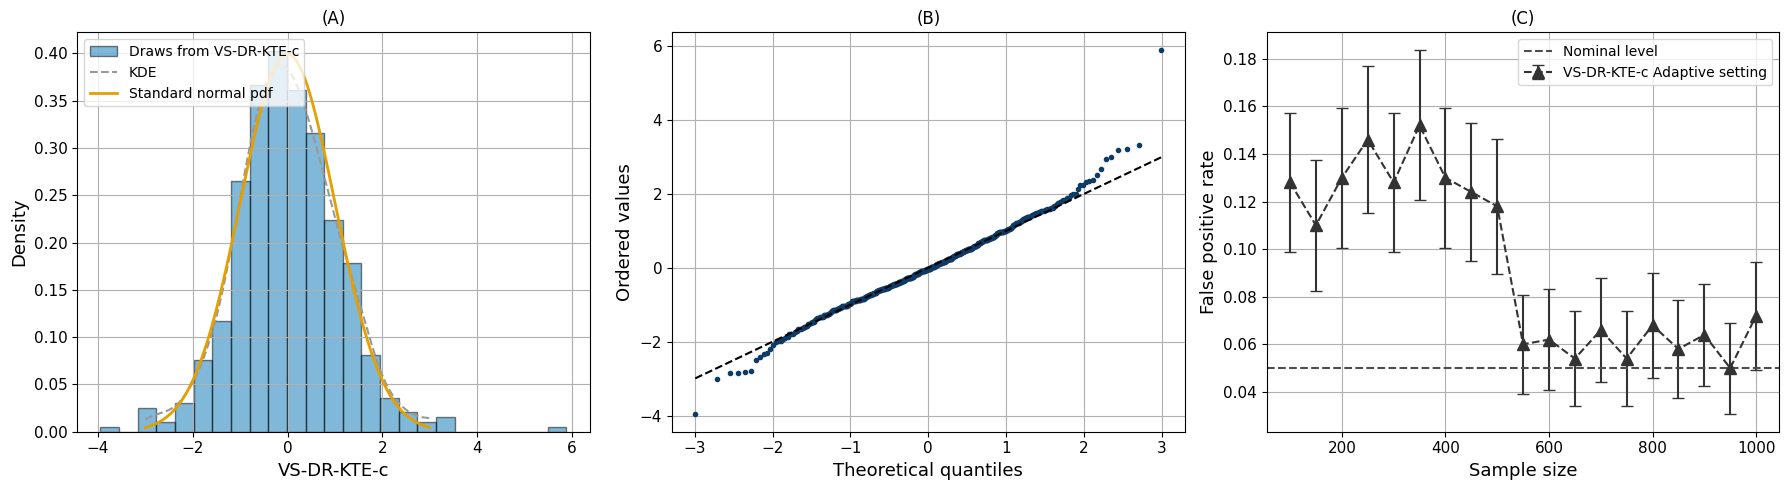

In [10]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot, gaussian_kde

# --- Styling (mimics your "sns-like" setup) ---
plt.rcParams["figure.figsize"] = (18, 5)
plt.rcParams["axes.grid"] = True
plt.rc("axes", labelsize=13)
plt.rc("xtick", labelsize=11)
plt.rc("ytick", labelsize=11)

# Colorblind-safe palette
cb_colors = {
    "hist": "#0072B2",     # blue
    "pdf": "#E69F00",      # orange
    "kde": "#999999",      # grey
    "qq": "#0D3B66",       # navy
    "nominal": "#4D4D4D"   # dark grey
}
# Per-method colors for panel (C)
method_colors = {
    "VS-DR-KTE": "#56B4E9",  # light blue
    "DR-xKTE":   "#009E73",  # green
    "IPW-xKTE":  "#CC79A7",  # pink
    "KTE":       "#F0E442"   # yellow (unused but available)
}
m_dict = {0: "^", 1: "s", 2: "v", 3: "o", 4: "D"}
m_dict_title = {0: " Adaptive setting", 1: " Observational setting", 2:"Adaptive Setting"}
method_dict = {'VS-DR-KTE': 'VS-DR-KTE-a', 'VS-DR-KTE_chronological': 'VS-DR-KTE-c', 'DR-xKTE': 'AIPW-xKTE', 'IPW-xKTE': 'IPW-xKTE', 'KTE': 'KTE'}

# --- Inputs matching your original snippet ---
case = 1
b = 'I'
ns = 750
method = 'VS-DR-KTE_chronological'
experiment = 'adaptive'
name_folder = f"results/{experiment}/"
os.makedirs("plots", exist_ok=True)

# ===================== (A) HIST + KDE + NORMAL PDF =====================
plt.subplot(1, 3, 1)
fname = f"{name_folder}ns{ns}b{b}{method}.csv"
stat_values = d[fname]['stat_values']
x_axis = np.linspace(-3, 3, 500)

# Histogram
plt.hist(
    stat_values,
    bins=25,
    density=True,
    color=cb_colors["hist"],
    alpha=0.5,
    edgecolor="black",
    label=f"Draws from {method_dict[method]}"
)

# KDE
kde = gaussian_kde(stat_values)
plt.plot(x_axis, kde(x_axis), linestyle="--", color=cb_colors["kde"], label="KDE")

# Standard Normal PDF
plt.plot(x_axis, norm.pdf(x_axis), linewidth=2, color=cb_colors["pdf"], label="Standard normal pdf")

plt.xlabel(method_dict[method])
plt.ylabel("Density")
plt.title("(A)")
plt.legend(loc="upper left")

# ============================== (B) QQ-PLOT ==============================
plt.subplot(1, 3, 2)
osm, osr = probplot(stat_values, dist="norm")[0]
plt.plot(osm, osr, marker='o', linestyle='', color=cb_colors["qq"], markersize=3)
plt.plot(osm, osm, color="black", linestyle="--")
plt.title("(B)")
plt.xlabel("Theoretical quantiles")
plt.ylabel("Ordered values")

# ===== (C) FALSE POSITIVE RATE (multi-method) WITH ERROR BARS =====
plt.subplot(1, 3, 3)
confidence_level = 0.05
method_list = ['VS-DR-KTE_chronological']
name_folder_list = [f"results/{experiment}/"]
ns_list = np.arange(100, 1050, 50)
ns_array = np.array(ns_list)

for k, nf in enumerate(name_folder_list):
    for i, mth in enumerate(method_list):
        rejection_proportion = np.zeros(len(ns_list))
        n_per_file = None

        for j, ns_val in enumerate(ns_list):
            f = f"{nf}ns{ns_val}b{b}{mth}.csv"
            pvals = d[f]['p_values']
            rejection_proportion[j] = (pvals < confidence_level).mean()
            n_per_file = len(pvals)  # assume constant across ns for varhat

        varhat = rejection_proportion * (1 - rejection_proportion) / n_per_file

        plt.errorbar(
            x=ns_array,
            y=rejection_proportion,
            yerr=1.96 * np.sqrt(varhat),
            capsize=4,
            marker=m_dict.get(k, "o"),
            markersize=8,
            color=method_colors.get(mth, "#333333"),
            linestyle='--',
            label=method_dict[mth] + m_dict_title[k]
        )

plt.axhline(confidence_level, color=cb_colors["nominal"], linestyle="--", label="Nominal level")
plt.title("(C)")
plt.xlabel("Sample size")
plt.ylabel("False positive rate")
plt.legend(loc="upper right")

plt.tight_layout()
plt.savefig(f"plots/REVIEWED_null_dr_adaptive{case}_errorbar.png", bbox_inches='tight')
plt.show()


## H1 scenarios II, III, IV

In [13]:
num_experiments=100
iterations=100

ns_list = np.arange(100, 450, 50)
b_list = ['II', 'III', 'IV']
method_list = ['VS-DR-KTE', 'CADR', 'Hadad']
# method_list = ['VS-DR-KTE', 'DR-xKTE', 'IPW-xKTE']


experiment = 'adaptive'
name_folder = 'results/' +str(experiment) + '/'
run_tests_adaptive(b_list, method_list, ns_list, name_folder, num_experiments, iterations, split="alternating")

b =  II
b =  III
b =  IV


In [14]:
# Scenario I adaptive setting
name_folder_list_adaptive_null = ['results/' + 'adaptive' + '/']
ns_list_false_null = ns_list
ns_array_false_null = np.array(ns_list_false_null)
b_list_false_null = ['II', 'III', 'IV']
methods_false_null = ['VS-DR-KTE', 'CADR', 'Hadad']
case_list_false_null = [1]

d = dict()

for name_folder in name_folder_list_adaptive_null:
    for b in b_list_false_null:
        for method in methods_false_null:
            for case in case_list_false_null:
                for ns in ns_array_false_null:
                    name = name_folder + 'ns' + str(ns) + 'b' + str(b) + method + '_alternating.csv'
                    d[name] = pd.read_csv(name, index_col = 0)

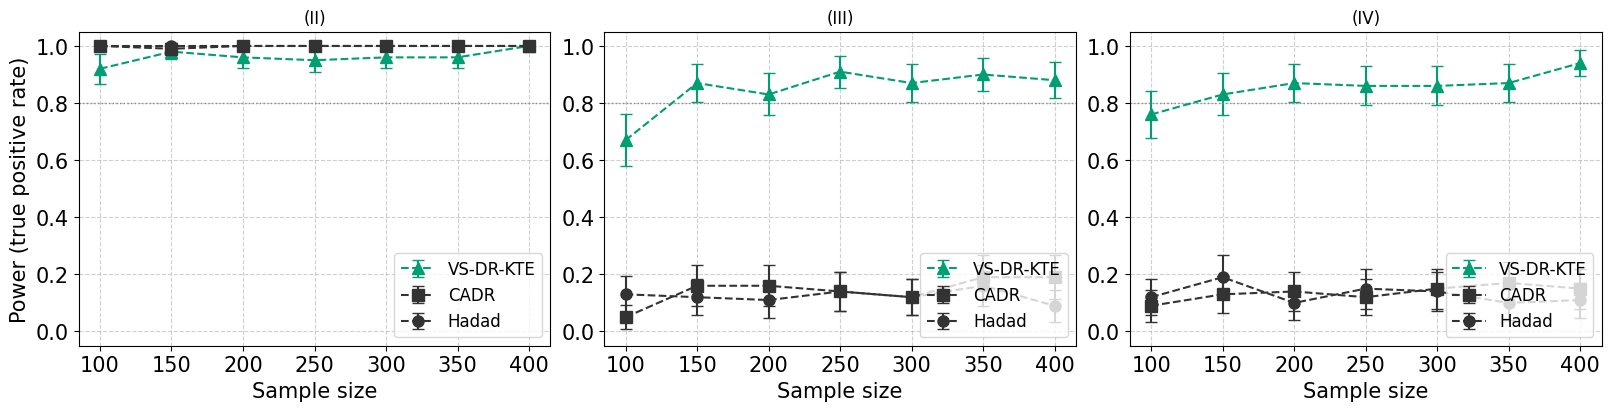

In [16]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_power_scenarios_adaptive_alternative(
    d,
    scenario_list=["II", "III", "IV"],
    ns_list=[100, 150, 200, 250, 300, 350, 400],
    methods=['VS-DR-KTE', 'CADR', 'Hadad'],
    name_folder="results/adaptive/",
    split_suffix="_alternating.csv",
    alpha=0.05,
    save_path="plots/adaptive_alternative_power.png"
):
    # === Styling ===
    plt.rcParams["figure.figsize"] = (16, 4)
    plt.rc("legend", fontsize=12)
    plt.rc("axes", labelsize=15)
    plt.rc("xtick", labelsize=15)
    plt.rc("ytick", labelsize=15)
    plt.rcParams["axes.grid"] = True

    fig, axs = plt.subplots(1, 3, constrained_layout=True)

    # === Mappings ===
    method_label = {
        "VS-DR-KTE": "VS-DR-KTE",
        "DR-xKTE": "DR-xKTE",
        "KTE": "KTE",
    }
    colors = {
        "VS-DR-KTE": "#009E73",
        "DR-xKTE": "#0072B2",
        "KTE": "#E69F00",
    }
    markers = {0: "^", 1: "s", 2: "o", 3: "v", 4: "D"}
    scenario_titles = {"II": "(II)", "III": "(III)", "IV": "(IV)"}
    ns_array = np.array(ns_list)

    for col, scenario in enumerate(scenario_list):
        ax = axs[col]
        ax.set_title(scenario_titles.get(scenario, scenario))
        ax.set_ylim((-0.05, 1.05))
        ax.set_xlabel("Sample size")
        ax.set_xticks(ns_list)
        ax.grid(True, linestyle="--", alpha=0.6)
        if col == 0:
            ax.set_ylabel("Power (true positive rate)")

        for i, method in enumerate(methods):
            power_values = []
            n_per_point = []
            for ns in ns_list:
                fname = f"{name_folder}ns{ns}b{scenario}{method}{split_suffix}"
                pvals = d[fname]["p_values"]
                rej = (pvals < alpha).mean()
                power_values.append(rej)
                n_per_point.append(len(pvals))

            power_values = np.array(power_values)
            n_per_point = np.array(n_per_point)
            # Binomial SE for proportion, Wald 95% band (you can swap for Wilson if you prefer)
            varhat = power_values * (1 - power_values) / np.maximum(n_per_point, 1)
            yerr = 1.96 * np.sqrt(varhat)

            ax.errorbar(
                x=ns_array,
                y=power_values,
                yerr=yerr,
                capsize=4,
                marker=markers[i % len(markers)],
                linestyle='--',
                linewidth=1.5,
                markersize=8,
                label=method_label.get(method, method),
                color=colors.get(method, "#333333")
            )

        # Reference lines: nominal alpha (for orientation) and 80% power target
        # ax.axhline(alpha, color="black", linestyle=":", linewidth=1, label="α")
        ax.axhline(0.8, color="#888888", linestyle=":", linewidth=1)

        ax.legend(loc="lower right")

    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches="tight")
    plt.show()

plot_power_scenarios_adaptive_alternative(
    d=d,
    scenario_list=['II','III','IV'],
    ns_list=ns_list,
    methods=['VS-DR-KTE', 'CADR', 'Hadad'],
    name_folder='results/adaptive/',
    split_suffix='_alternating.csv',
    alpha=0.05,
    save_path='plots/scenarios_II_III_IV_adaptive_power.png'
)